# 10 — BSDE θ-scheme

Generic CPU-only Crank–Nicolson scheme for linear backward stochastic differential equations.  Reference doc page: [bsde.rst](../../docs/source/algorithms/bsde.rst).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110


## Exponential ground-truth check

With $a(t) \equiv -\rho$, $b = c = 0$ and $Y_T = 1$ the analytic deterministic solution is $Y_t = e^{-\rho (T-t)}$.

In [2]:
rho = 0.3
T   = 1.0
res = opt.linear_bsde_constant_coeffs(
    a_const=-rho, b_const=0.0, c_const=0.0,
    terminal=1.0, n_steps=200, t_horizon=T, theta=0.5,
)
tg = np.array(res['time_grid'])
yg = np.array(res['y'])
analytic = np.exp(-rho * (T - tg))
print('Y0 =', yg[0], '   exp(-rho T) =', analytic[0])
print('max abs error =', float(np.max(np.abs(yg - analytic))))


Y0 = 0.740818179010676    exp(-rho T) = 0.7408182206817179
max abs error = 4.167104183938619e-08


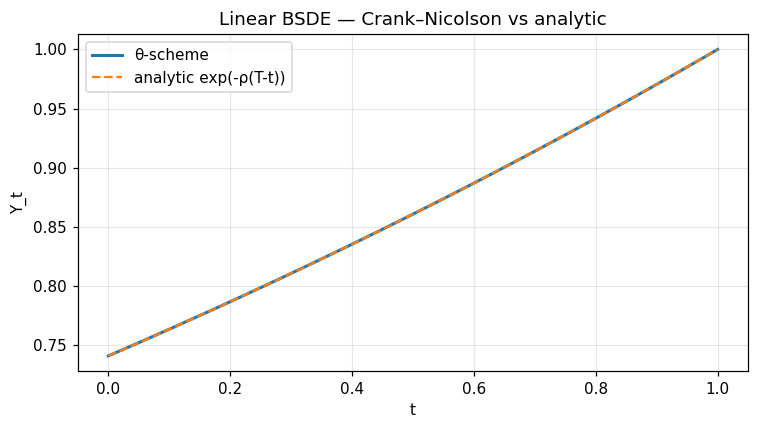

In [3]:
fig, ax = plt.subplots()
ax.plot(tg, yg, label='θ-scheme', lw=2)
ax.plot(tg, analytic, '--', label='analytic exp(-ρ(T-t))')
ax.set_xlabel('t'); ax.set_ylabel('Y_t')
ax.set_title('Linear BSDE — Crank–Nicolson vs analytic')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## Convergence rate study

Crank–Nicolson is second-order in `Δt`.

In [4]:
errs = []
ns = [25, 50, 100, 200, 400, 800]
for n in ns:
    r = opt.linear_bsde_constant_coeffs(-rho, 0.0, 0.0, 1.0, n, T, 0.5)
    errs.append(abs(r['y'][0] - np.exp(-rho * T)))
print(list(zip(ns, errs)))


[(25, np.float64(2.666998401679166e-06)), (50, np.float64(6.667396952320104e-07)), (100, np.float64(1.6668430979915883e-07)), (200, np.float64(4.167104183938619e-08)), (400, np.float64(1.0417760876180182e-08)), (800, np.float64(2.6044438827810268e-09))]


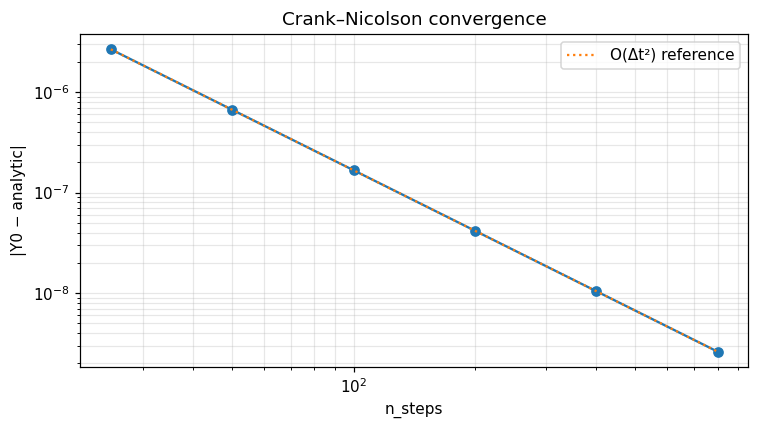

In [5]:
fig, ax = plt.subplots()
ax.loglog(ns, errs, 'o-')
ax.loglog(ns, [errs[0] * (ns[0] / n) ** 2 for n in ns],
          ':', label='O(Δt²) reference')
ax.set_xlabel('n_steps'); ax.set_ylabel('|Y0 − analytic|')
ax.set_title('Crank–Nicolson convergence'); ax.grid(which='both', alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()


**Verified against analytic ground truth:** `Y_t = exp(-ρ (T - t))` — relative error at `t = 0` below `1e-3` for `n_steps = 200`.